In [21]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.datasets import mnist

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Flatten
)

from tensorflow.keras.utils import to_categorical

In [23]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [24]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


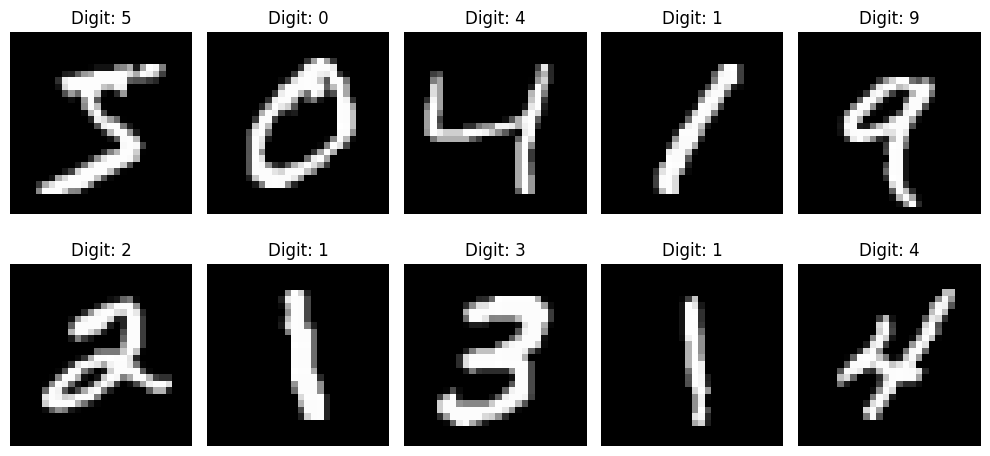

In [25]:
plt.figure(figsize=(10,5))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(
        X_train[i],
        cmap='gray'
    )
    
    plt.title(f"Digit: {y_train[i]}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [27]:
y_train = to_categorical(y_train)

y_test = to_categorical(y_test)

In [28]:
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Dropout
)

model = Sequential([
    
    Flatten(input_shape=(28,28)),
    
    Dense(128, activation='relu'),
    
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    
    Dropout(0.3),
    
    Dense(10, activation='softmax')
])

In [29]:
model.compile(
    optimizer='adam',
    
    loss='categorical_crossentropy',
    
    metrics=['accuracy']
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    
    epochs=5,
    
    batch_size=32,
    
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8692 - loss: 0.4330 - val_accuracy: 0.9534 - val_loss: 0.1594
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9368 - loss: 0.2153 - val_accuracy: 0.9620 - val_loss: 0.1303
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9490 - loss: 0.1731 - val_accuracy: 0.9688 - val_loss: 0.1036
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9572 - loss: 0.1437 - val_accuracy: 0.9699 - val_loss: 0.1034
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9612 - loss: 0.1288 - val_accuracy: 0.9725 - val_loss: 0.0934


In [31]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9716 - loss: 0.0881
Accuracy: 0.9715999960899353


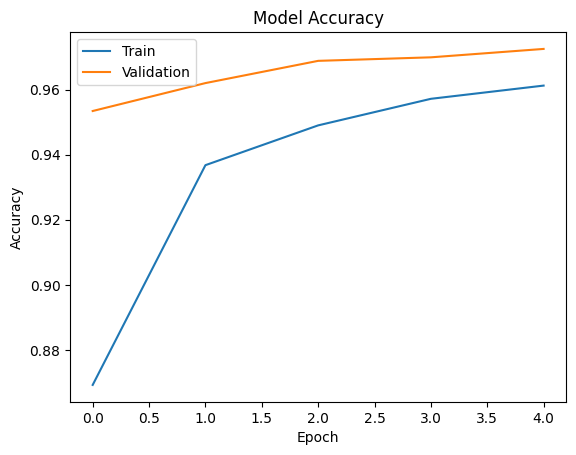

In [32]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

In [33]:
predictions = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [34]:
predicted_digit = np.argmax(predictions[0])

print("Predicted Digit:", predicted_digit)

Predicted Digit: 7


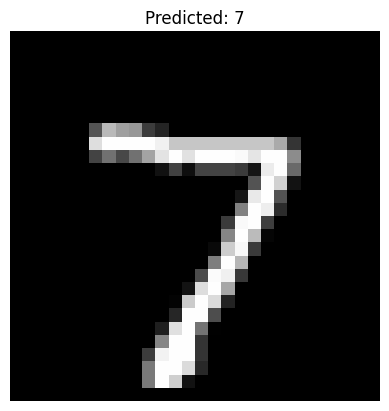

In [35]:
plt.imshow(
    X_test[0],
    cmap='gray'
)

plt.title(f"Predicted: {predicted_digit}")

plt.axis('off')

plt.show()

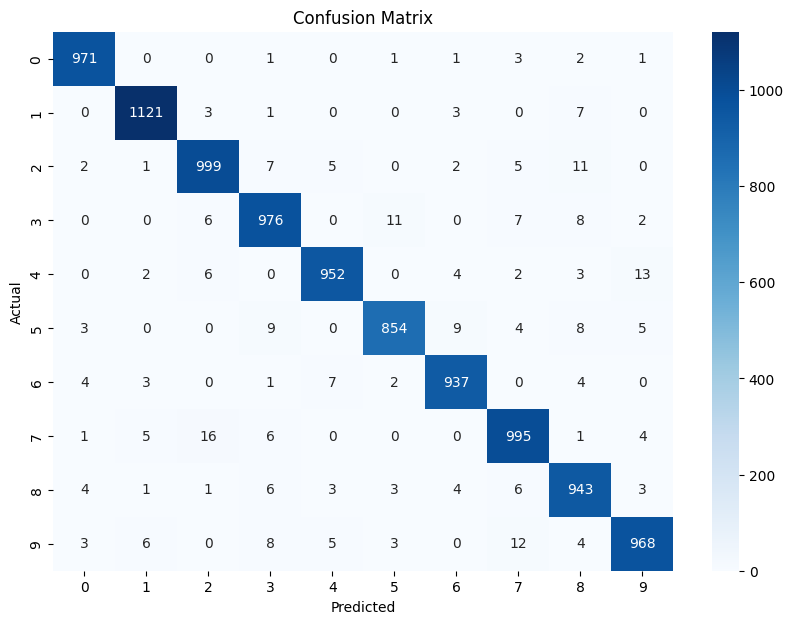

In [36]:
y_pred = np.argmax(predictions, axis=1)

y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [37]:
print(
    classification_report(
        y_true,
        y_pred
    )
)


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.96      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.96      0.97      0.97      1028
           8       0.95      0.97      0.96       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [38]:
model.save(
    "models/handwritten_digit_nn.h5"
)